## Importamos todas las librerías que vamos a necesitar

In [11]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt


## Importamos los Datasets a df

In [2]:
try:
  # Import the datasets into pandas DataFrames
  df = pd.read_csv('student_lifestyle_dataset.csv')

  print("Datasets imported successfully!")

except FileNotFoundError:
  print("One or more files not found. Check the file paths.")
except pd.errors.ParserError:
  print("Error parsing one or more CSV files. Check file format.")
except Exception as e:
  print(f"An error occurred: {e}")

Datasets imported successfully!


# Visualización de los datos y análisis exploratorio

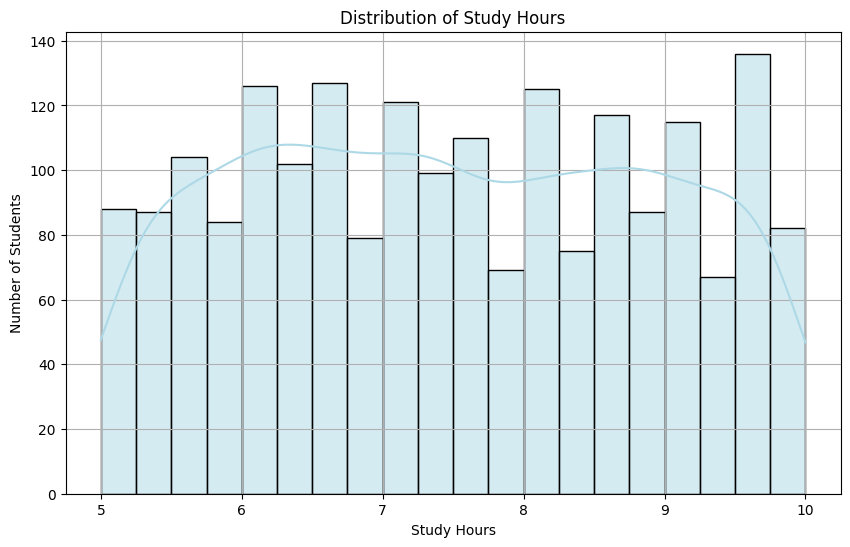

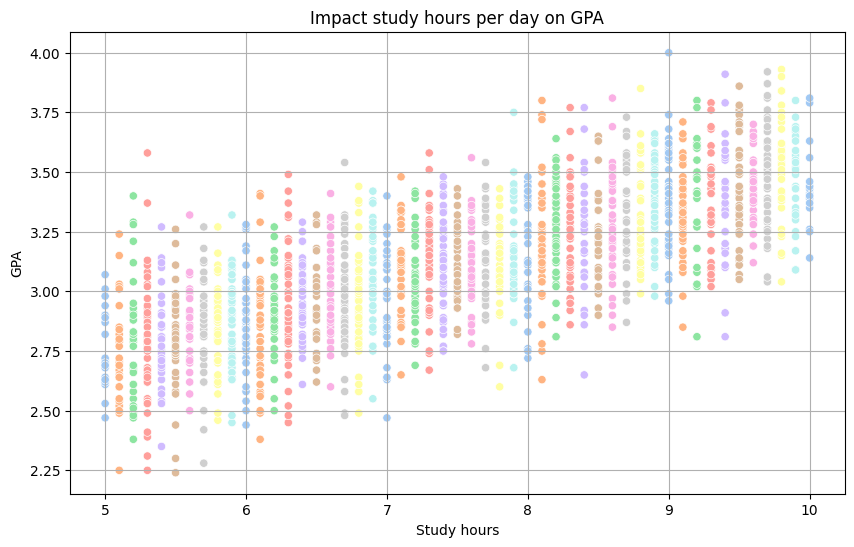

In [3]:
# 1. Distribution of Study Hours
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Study_Hours_Per_Day', bins=20, kde=True, color='lightblue')
plt.title('Distribution of Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Number of Students')
plt.grid()
plt.show()

# 3. Impact of Online Courses on Final Grades
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Study_Hours_Per_Day', y='GPA', hue='Study_Hours_Per_Day', palette='pastel', legend=False)
plt.title('Impact study hours per day on GPA')
plt.xlabel('Study hours')
plt.ylabel('GPA')
plt.grid()
plt.show()

# Evaluación del modelo con clustering

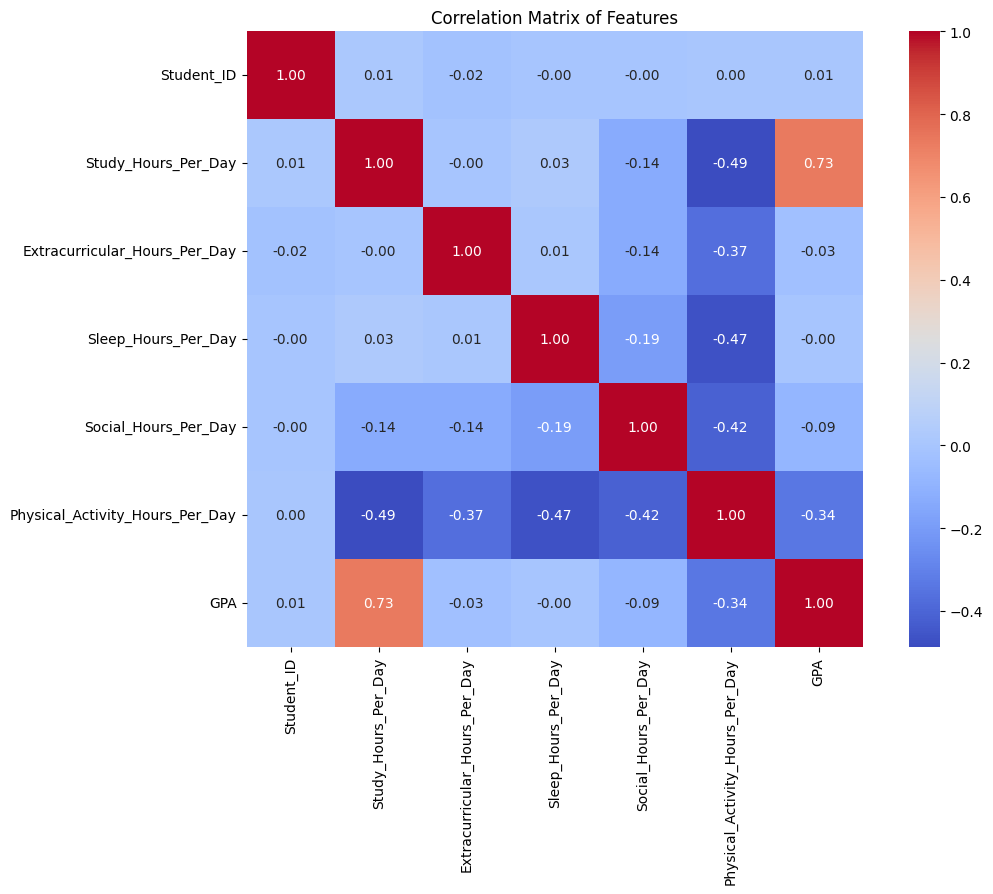

In [4]:
# Step 1: Select all relevant features for correlation analysis
features = df.select_dtypes(include=[np.number])  # Selecting only numeric features

# Step 2: Display the correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = features.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Features')
plt.show()

# Modelo de prueba con Polynomial Features

In [5]:
# 1. Carga y mapeo (asegurando limpieza)
df = pd.read_csv('student_lifestyle_dataset.csv')
mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Level'] = df['Stress_Level'].map(mapping)

# 2. Selección de X (Quitamos ID y Target)
X = df.drop(['GPA', 'Student_ID'], axis=1)

# --- EL PASO DE LIMPIEZA TOTAL ---
# Reemplazamos cualquier infinito por NaN y luego borramos cualquier fila con NaN
X = X.replace([np.inf, -np.inf], np.nan).dropna()
# Alineamos 'y' para que tenga las mismas filas que X tras el dropna
y = df.loc[X.index, 'GPA']

# 3. Transformación Polinómica
poly = PolynomialFeatures(degree=2, include_bias=False)

try:
    X_poly = poly.fit_transform(X)
    print("¡Logrado! Matriz polinómica creada.")
    print(f"Nuevas dimensiones: {X_poly.shape}")
except ValueError as e:
    print(f"Error persistente: {e}")
    # Si falla, vamos a inspeccionar qué fila tiene el problema
    print("Filas con problemas:", X.isnull().any(axis=1).sum())

¡Logrado! Matriz polinómica creada.
Nuevas dimensiones: (2000, 27)


In [6]:
# 1. División de datos (usando la matriz polinómica que ya funciona)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# 2. Configuración "Cazadora de R²"
modelo_final = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.03,    # Un poco más lento para no pasarse de largo
    max_depth=5,           # Profundidad moderada para captar las interacciones polinómicas
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,         # Regularización L1 para "apagar" variables polinómicas inútiles
    reg_lambda=1.0,        # Regularización L2 para estabilidad
    random_state=42,
    early_stopping_rounds=50
)

# 3. Entrenamiento
modelo_final.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 4. Resultados
y_pred = modelo_final.predict(X_test)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(f"--- RESULTADOS FINALES ---")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")

--- RESULTADOS FINALES ---
R² Score: 0.5153
MSE: 0.0453


# Modelo  de prueba con árboles de decisión

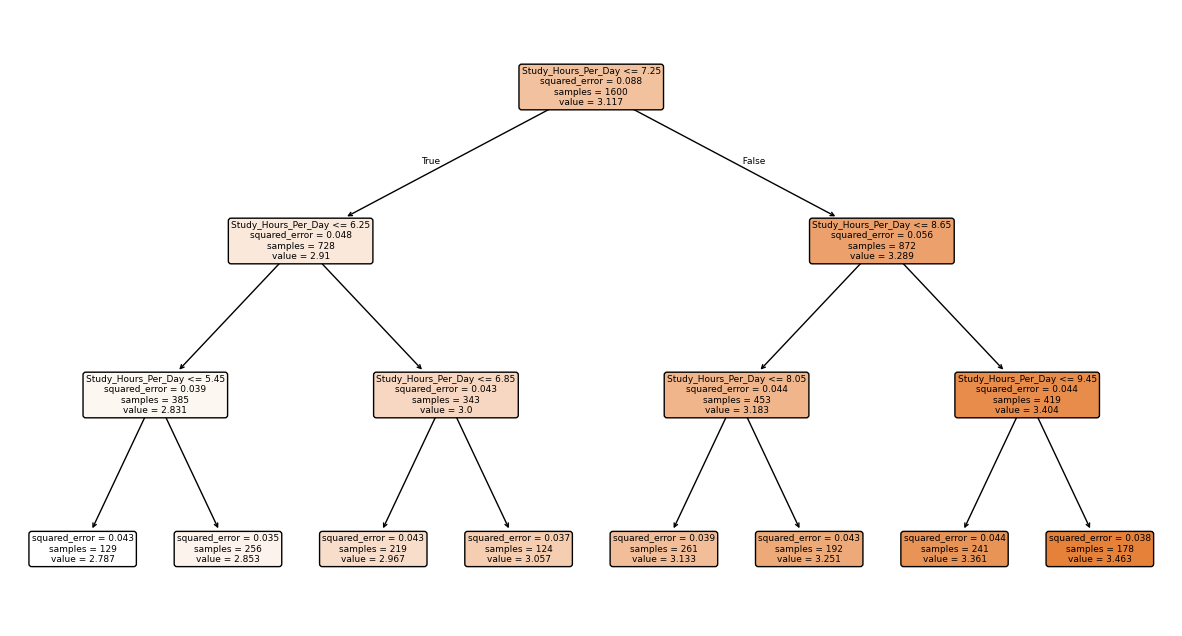

In [7]:

# 1. Seleccionamos variables que influyen directamente
X = df[['Study_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day']]
y = df['GPA']

# 2. Dividimos los datos para probar el modelo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenamos un árbol sencillo (limitamos la profundidad para que sea legible)
model = DecisionTreeRegressor(max_depth=3) 
model.fit(X_train, y_train)

# 4. ¡Visualizamos las reglas!
plt.figure(figsize=(15,8))
plot_tree(model, feature_names=X.columns, filled=True, rounded=True)
plt.show()

# Entrenamiento de modelos con distintas estrategias

Cogemos unas columnas que a simple vista nos parecen importantes para hacer el split de train y test.

In [8]:

# Supongamos que X son tus columnas de estudio y y es la nota final
X = df[['Study_Hours_Per_Day']]
y = df['GPA']

# Dividimos: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Probamos tres enfoques distintos para nuestro modelo

In [9]:
# Definimos los competidores
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Árbol de Decisión": DecisionTreeRegressor(max_depth=5),
    "Random Forest": RandomForestRegressor(n_estimators=100)
}

# Probamos cada uno
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train) # Entrenamiento
    predicciones = modelo.predict(X_test) # Predicción
    
    # Métricas
    mae = mean_absolute_error(y_test, predicciones)
    r2 = r2_score(y_test, predicciones)
    
    print(f"--- {nombre} ---")
    print(f"Error promedio (MAE): {mae:.2f} puntos")
    print(f"Precisión (R2 Score): {r2:.2f}")
    print("-" * 20)

--- Regresión Lineal ---
Error promedio (MAE): 0.16 puntos
Precisión (R2 Score): 0.55
--------------------
--- Árbol de Decisión ---
Error promedio (MAE): 0.17 puntos
Precisión (R2 Score): 0.53
--------------------
--- Random Forest ---
Error promedio (MAE): 0.17 puntos
Precisión (R2 Score): 0.52
--------------------


# Probamos a entrenar nuestro modelo con xgboost

In [10]:
# Limpiamos los outliers influyentes
# Eliminar registros donde el GPA sea sospechosamente bajo o las horas imposibles
df_clean = df[(df['GPA'] > 0) & (df['Study_Hours_Per_Day'] > 0)].copy()

# Opcional: Usar el Z-score para quitar valores muy alejados de la media
from scipy import stats
df_clean = df_clean[(np.abs(stats.zscore(df_clean.select_dtypes(include=[np.number]))) < 3).all(axis=1)]

In [11]:
# Para poder trabajar con trodas las variables, tengo que ajustar Stress_Level, ya que es un string. Lo transformaré a categórica.

# Definimos el mapa de orden
orden_estres = {'Low': 0, 'Moderate': 1, 'High': 2}

# Aplicamos la transformación
df['Stress_Level'] = df['Stress_Level'].map(orden_estres)

Creamos una nueva columna para saber las horas de actividad total del alumno

In [12]:
# Sumamos las horas de estudio, actividades extracurriculares, sociales y físicas
columnas_actividad = [
    'Study_Hours_Per_Day', 
    'Extracurricular_Hours_Per_Day', 
    'Social_Hours_Per_Day', 
    'Physical_Activity_Hours_Per_Day'
]

# Creamos la nueva columna
df['Total_Active_Hours'] = df[columnas_actividad].sum(axis=1)

# Opcional: Crear una variable de "Balance" (Sueño vs Actividad)
# Un valor alto indica un estilo de vida muy cargado que podría afectar el GPA
df['Activity_Sleep_Ratio'] = df['Total_Active_Hours'] / df['Sleep_Hours_Per_Day']

print(df[['Total_Active_Hours', 'Activity_Sleep_Ratio', 'GPA']].head())

   Total_Active_Hours  Activity_Sleep_Ratio   GPA
0                15.3              1.758621  2.99
1                16.0              2.000000  2.75
2                14.8              1.608696  2.67
3                16.8              2.333333  2.88
4                17.5              2.692308  3.51


In [13]:
# Separamos la variable target de los datos

# 1. Separar X e y
X = df.drop(['GPA', 'Student_ID'], axis=1)
y = df['GPA']

# # 1. Definir el modelo con los parámetros de parada temprana AQUÍ
modelo_optimizado = xgb.XGBRegressor(
    max_depth=4,
    learning_rate=0.05,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    # MOVIDO AQUÍ:
    early_stopping_rounds=30 
)

# 2. En el .fit() ahora solo pasas el eval_set
modelo_optimizado.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# 3. Predicciones (Asegúrate de usar el nombre correcto: modelo_optimizado)
y_pred = modelo_optimizado.predict(X_test)

# 4. Evaluación
print(f"R² Score: {r2_score(y_test, y_pred)}")
print(f"MSE: {mean_squared_error(y_test, y_pred)}")

R² Score: 0.5310431396113587
MSE: 0.04378332926822887


Probamos combinando tres modelos distintos

In [ ]:
# 1. Preparamos los datos (usa el X_poly si quieres mantener la potencia polinómica)
# Si no, usa el X normal con el escudo contra infinitos que funcionó.
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

print(f"Entrenando con {X_train.shape[0]} muestras y probando con {X_test.shape[0]}")

# Definimos los 3 modelos con parámetros que eviten el sobreajuste
m1 = xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)

m2 = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42)

m3 = GradientBoostingRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, random_state=42)

# Creamos el Ensamble (VotingRegressor)
# El 'voter' promediará las predicciones de los tres modelos
voter = VotingRegressor([
    ('xgb', m1),
    ('rf', m2),
    ('gb', m3)
])

# Entrenamos el ensamble
voter.fit(X_train, y_train)

# Predicción final
y_pred = voter.predict(X_test)

# Evaluación definitiva
from sklearn.metrics import r2_score, mean_squared_error
print(f"R² Final Combinado: {r2_score(y_test, y_pred):.4f}")

Entrenando con 1600 muestras y probando con 400
R² Final Combinado: 0.4933


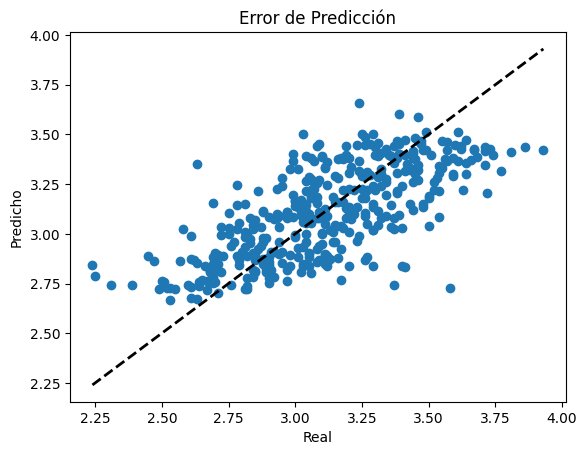

In [15]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Real')
plt.ylabel('Predicho')
plt.title('Error de Predicción')
plt.show()

Hasta ahora, lo que mejor nos ha funcionado es la regresión lineal, así que vamos a insistir más en ello, probando nuevas estrategias.

# LASSO

In [12]:
# 1. Escalar las variables (Obligatorio para LASSO)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly) # Usa tu matriz polinómica

# 2. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Encontrar el mejor alfa
# LassoCV prueba varios alphas y elige el mejor
modelo_lasso = LassoCV(alphas=None, cv=5, max_iter=10000, random_state=42)
modelo_lasso.fit(X_train, y_train)

print(f"Mejor valor de Alpha: {modelo_lasso.alpha_}")

# Predicción y evaluación
y_pred = modelo_lasso.predict(X_test)
print(f"R² con LASSO: {r2_score(y_test, y_pred):.4f}")


NameError: name 'X_poly' is not defined

# Ridge

In [7]:

# 1. Carga y Limpieza (Escudo contra infinitos)
df = pd.read_csv('student_lifestyle_dataset.csv')
mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Level'] = df['Stress_Level'].map(mapping)

# Eliminamos IDs y el target, y limpiamos cualquier valor extraño
X = df.drop(['GPA', 'Student_ID'], axis=1)
y = df['GPA']
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())

# 2. DIVISIÓN DE DATOS (Train/Test Split)
# Lo hacemos ANTES de cualquier transformación para evitar "data leakage"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. PIPELINE DE MÁXIMA PRECISIÓN
# Escalamos -> Creamos interacciones (Polinomios) -> Aplicamos Ridge
scaler = StandardScaler()
poly = PolynomialFeatures(degree=2, include_bias=False)

# Transformamos entrenamiento
X_train_scaled = scaler.fit_transform(X_train)
X_train_poly = poly.fit_transform(X_train_scaled)

# Transformamos prueba (usando los parámetros de entrenamiento)
X_test_scaled = scaler.transform(X_test)
X_test_poly = poly.transform(X_test_scaled)

# 4. MODELO RIDGE CV (Encuentra el mejor compromiso automáticamente)
modelo_ridge = RidgeCV(alphas=np.logspace(-6, 6, 13))
modelo_ridge.fit(X_train_poly, y_train)

# 5. EVALUACIÓN
y_pred = modelo_ridge.predict(X_test_poly)
r2 = r2_score(y_test, y_pred)

print(f"R² Score con Ridge Polinómico: {r2:.6f}")
print(f"Mejor Alpha encontrado: {modelo_ridge.alpha_}")

R² Score con Ridge Polinómico: 0.536892
Mejor Alpha encontrado: 10.0


# Modelo final: Regresión lineal

In [18]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1. Carga y limpieza (Aseguramos que no haya nulos ni infinitos)
df = pd.read_csv('student_lifestyle_dataset.csv')
mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Level'] = df['Stress_Level'].map(mapping)

# Definimos X e y (Sin Student_ID ni GPA)
X = df.drop(['GPA', 'Student_ID'], axis=1)
y = df['GPA']

# ESCUDO FINAL: Limpiamos cualquier valor no finito que cause errores
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())

# 2. División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Creación y entrenamiento del modelo (Regresión Lineal Simple)
# Como la lineal es la que manda, la usamos pura para máxima precisión
modelo_final = LinearRegression()
modelo_final.fit(X_train, y_train)

# 4. Predicciones y Evaluación
y_pred = modelo_final.predict(X_test)
r2_final = r2_score(y_test, y_pred)

print(f"R² Final en Test: {r2_final:.6f}")

# 5. Validación Cruzada (Para confirmar que el 0.53 es sólido)
cv_scores = cross_val_score(modelo_final, X, y, cv=5)
print(f"R² Promedio (Cross-Validation): {cv_scores.mean():.6f}")

from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Error promedio (RMSE): {rmse:.3f} puntos de GPA")

R² Final en Test: 0.549393
R² Promedio (Cross-Validation): 0.536151
Error promedio (RMSE): 0.205 puntos de GPA


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Calculamos el Error Cuadrático Medio y su Raíz (RMSE)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# 2. Calculamos el Error Absoluto Medio (MAE)
mae = mean_absolute_error(y_test, y_pred)

print(f"--- MÉTRICAS DE ERROR REAL ---")
print(f"MAE (Error promedio): {mae:.4f} puntos de GPA")
print(f"RMSE (Penaliza errores grandes): {rmse:.4f} puntos de GPA")

# 3. Comparación con el rango de la nota
rango_gpa = y.max() - y.min()
print(f"\nRango total de GPA en el dataset: {rango_gpa:.2f}")
print(f"El error representa aproximadamente un { (mae / rango_gpa) * 100:.2f}% del rango total.")

--- MÉTRICAS DE ERROR REAL ---
MAE (Error promedio): 0.1639 puntos de GPA
RMSE (Penaliza errores grandes): 0.2051 puntos de GPA

Rango total de GPA en el dataset: 1.76
El error representa aproximadamente un 9.31% del rango total.


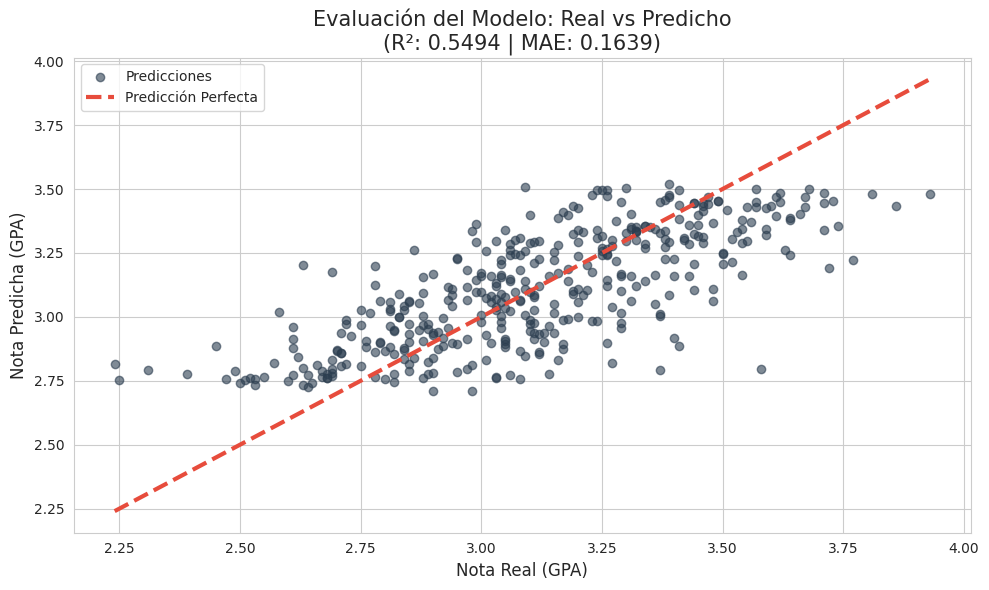

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar el estilo
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 2. Crear el gráfico de dispersión
# Comparamos y_test (real) vs y_pred (predicho)
plt.scatter(y_test, y_pred, alpha=0.6, color='#2c3e50', label='Predicciones')

# 3. Dibujar la línea de "Predicción Perfecta" (Diagonal)
# Si el modelo fuera perfecto, todos los puntos estarían sobre esta línea
perfect_line = [y_test.min(), y_test.max()]
plt.plot(perfect_line, perfect_line, color='#e74c3c', linestyle='--', lw=3, label='Predicción Perfecta')

# 4. Añadir etiquetas y títulos con tus métricas reales
plt.title(f'Evaluación del Modelo: Real vs Predicho\n(R²: {r2_final:.4f} | MAE: 0.1639)', fontsize=15)
plt.xlabel('Nota Real (GPA)', fontsize=12)
plt.ylabel('Nota Predicha (GPA)', fontsize=12)
plt.legend()

# 5. Mostrar el gráfico
plt.tight_layout()
plt.show()

# Conclusión

Con ninguna de las estrategias utilizadas para crear un modelo con una buena predicción hemos conseguido superar un R² de 0.55. Esto no significa que los modelos sean malos, sino que la base de datos no explica gran parte de los facotres que influyen en el GPA. Del mismo modo, es normal que en datasets de estudiantes haya mucho ruido, ya que hay muchas variables que no podemos tener en cuenta. Además, una vez calculadas las métricas de error real, podemos determinar, que nuestro es modelo es muy bueno, ya que el error absoluto medio es de apenas 0.16 puntos de GPA, lo que representa una precisión del 90.7% respecto al rango de notas del dataset. Esto confirma que las horas de estudio, sueño y el nivel de estrés son predictores sólidos y fiables para estimar el éxito estudiantil."
